# CVXPY Workshop (2/20/2026)

## Preliminaries

In [1]:
# imports
import matplotlib.pyplot as plt
from eeco import emissions
from eeco.units import u
from eeco import costs
import pandas as pd
import cvxpy as cp
import datetime

In [2]:
path_to_tariff_sheet = "sbce_billing.csv"
start_dt = datetime.datetime(2023, 4, 9)
end_dt = datetime.datetime(2023, 4, 11)

In [21]:
# load a tariff spreadsheet
tariff_df = pd.read_csv(path_to_tariff_sheet, sep=",")
# get the charge dictionary
charge_dict = costs.get_charge_dict(start_dt, end_dt, tariff_df, resolution="1m")
# load historical consumption data
load_df = pd.read_csv("consumption.csv", parse_dates=["Datetime"])
# NOTE: second entry of the tuple can be ignored since it's for Pyomo
baseline_electricity_cost, _ = costs.calculate_itemized_cost(
    charge_dict,
    {"electric": load_df["Load [kW]"].values * 1000},
    resolution="1m",
    desired_utility="electric",
    demand_scale_factor=2/30,
)
total_baseline_cost = (
    baseline_electricity_cost["electric"]["demand"] + baseline_electricity_cost["electric"]["energy"]
)
print(f"Baseline Electricity Cost: ${total_baseline_cost:.2f}")

Baseline Electricity Cost: $17212.32


/var/folders/x0/tw3_vnp167j29gkn361pc3l40000gp/T/ipykernel_85315/3955482337.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  load_df = pd.read_csv("consumption.csv", parse_dates=["Datetime"])


In [4]:
# create variables for battery total energy, max charge and discharge power, and SOC limits
total_capacity = 10 # kWh
min_soc = 0
max_soc = 1
init_soc = 0.5
fin_soc = 0.5
max_discharge = 5 # kW
max_charge = 5 # kW
T = len(load_df["Datetime"])
delta_t = ((load_df.iloc[-1]["Datetime"] - load_df.iloc[0]["Datetime"]) / T) / datetime.timedelta(hours=1)

# initialize variables
battery_output_kW = cp.Variable(T)
battery_soc = cp.Variable(T+1)
grid_demand_kW = cp.Variable(T)

# set constraints
constraints = [
    battery_output_kW >= -max_discharge,
    battery_output_kW <= max_charge,
    battery_soc >= min_soc,
    battery_soc <= max_soc,
    battery_soc[0] == init_soc,
    battery_soc[T] == fin_soc,
    grid_demand_kW >= 0
]
for t in range(T):
    constraints += [
        battery_soc[t+1] == battery_soc[t] + (battery_output_kW[t] * delta_t) / total_capacity,
        grid_demand_kW[t] == load_df.iloc[t]["Load [kW]"] + battery_output_kW[t]
    ]

In [5]:
# requires a consumption dictionary in case there is natural gas
consumption_data_dict = {"electric": grid_demand_kW}
itemized_cost, _ = costs.calculate_itemized_cost(
    charge_dict,
    {"electric": grid_demand_kW},
    resolution="1m",
    consumption_estimate=load_df["Load [kW]"].sum(),
    desired_utility="electric",
    demand_scale_factor=2/30,
)
obj = itemized_cost["electric"]["energy"] + itemized_cost["electric"]["demand"]
# solve the CVX problem
prob = cp.Problem(cp.Minimize(obj), constraints)
prob.solve()
# always compute the ex-post cost using NumPy due to the convex relaxations
cost_opt_elec_cost, _ = costs.calculate_itemized_cost(
    charge_dict,
    {"electric": grid_demand_kW.value * 1000},
    resolution="1m",
    desired_utility="electric",
    demand_scale_factor=2/30,
)

In [7]:
total_cost_opt = (
    cost_opt_elec_cost["electric"]["demand"] + cost_opt_elec_cost["electric"]["energy"]
)
print(f"Cost Optimized Electricity Cost: ${total_cost_opt:.2f}")
cost_opt_demand = grid_demand_kW.value.copy()

Cost Optimized Electricity Cost: $8974.86


In [8]:
# create variables for battery total energy, max charge and discharge power, and SOC limits
total_capacity = 10 # kWh
min_soc = 0
max_soc = 1
init_soc = 0.5
fin_soc = 0.5
max_discharge = 5 # kW
max_charge = 5 # kW
T = len(load_df["Datetime"])
delta_t = ((load_df.iloc[-1]["Datetime"] - load_df.iloc[0]["Datetime"]) / T) / datetime.timedelta(hours=1)

# initialize variables
battery_output_kW = cp.Variable(T)
battery_soc = cp.Variable(T+1)
grid_demand_kW = cp.Variable(T)

# set constraints
constraints = [
    battery_output_kW >= -max_discharge,
    battery_output_kW <= max_charge,
    battery_soc >= min_soc,
    battery_soc <= max_soc,
    battery_soc[0] == init_soc,
    battery_soc[T] == fin_soc,
    grid_demand_kW >= 0
]
for t in range(T):
    constraints += [
        battery_soc[t+1] == battery_soc[t] + (battery_output_kW[t] * delta_t) / total_capacity,
        grid_demand_kW[t] == load_df.iloc[t]["Load [kW]"] + battery_output_kW[t]
    ]

In [9]:
emission_df = pd.read_csv("emissions.csv", sep=",")
# get the carbon intensity
carbon_intensity = emissions.get_carbon_intensity(
    datetime.datetime(2023, 4, 9), datetime.datetime(2023, 4, 11), emission_df, resolution="1m"
)
# NOTE: this value is arbitrary, but you'd pick your desired cost of carbon
cost_of_carbon = 10
emissions_obj, _ = emissions.calculate_grid_emissions(
    carbon_intensity,
    grid_demand_kW,
    resolution="1m",
    consumption_units=u.kW
)
itemized_cost, _ = costs.calculate_itemized_cost(
    charge_dict,
    {"electric": grid_demand_kW},
    resolution="1m",
    consumption_estimate=load_df["Load [kW]"].sum(),
    desired_utility="electric",
    demand_scale_factor=2/30,
)
obj = (
    itemized_cost["electric"]["energy"] + itemized_cost["electric"]["demand"] 
    + emissions_obj * cost_of_carbon
)
# solve the CVX problem
prob = cp.Problem(cp.Minimize(obj), constraints)
prob.solve()
# always compute the ex-post cost using NumPy due to the convex relaxations
co_opt_elec_cost, _ = costs.calculate_itemized_cost(
    charge_dict,
    {"electric": grid_demand_kW.value * 1000},
    resolution="1m",
    desired_utility="electric",
    demand_scale_factor=2/30
)

In [10]:
total_co_opt = (
    co_opt_elec_cost["electric"]["demand"] + co_opt_elec_cost["electric"]["energy"]
)
print(f"Co-optimized Electricity Cost: ${total_co_opt:.2f}")
co_opt_demand = grid_demand_kW.value.copy()

Co-optimized Electricity Cost: $12161.40


## Plot Results

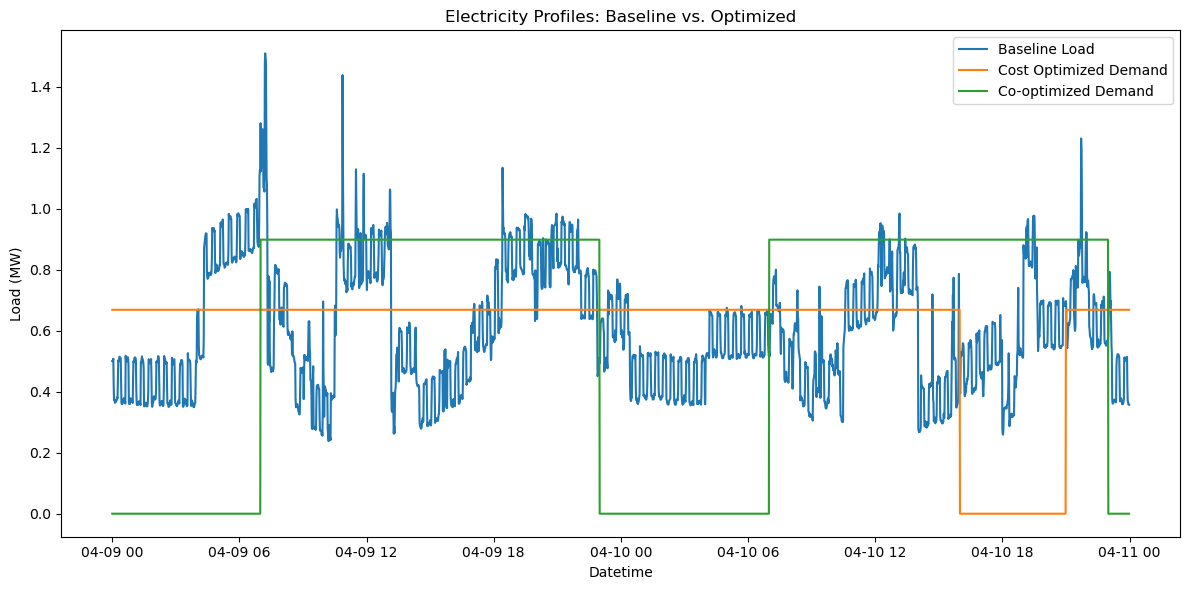

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(load_df["Datetime"], load_df["Load [kW]"], label="Baseline Load")
plt.plot(load_df["Datetime"], cost_opt_demand, label="Cost Optimized Demand")
plt.plot(load_df["Datetime"], co_opt_demand, label="Co-optimized Demand")
plt.xlabel("Datetime")
plt.ylabel("Load (MW)")
plt.title("Electricity Profiles: Baseline vs. Optimized")
plt.legend()
# plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
baseline_emissions, _ = emissions.calculate_grid_emissions(
    carbon_intensity,
    load_df["Load [kW]"].values * 1000,
    resolution="1m",
    consumption_units=u.kW
)

cost_optimized_electricity_cost_value = total_cost_opt # Store the value from the previous cost optimization
cost_optimized_emissions, _ = emissions.calculate_grid_emissions(
    carbon_intensity,
    cost_opt_demand * 1000,
    resolution="1m",
    consumption_units=u.kW
)

co_optimized_electricity_cost_value = total_co_opt # Store the value from the co-optimization
co_optimized_emissions, _ = emissions.calculate_grid_emissions(
    carbon_intensity,
    co_opt_demand * 1000,
    resolution="1m",
    consumption_units=u.kW
)

results = pd.DataFrame({
    'Scenario': ['Baseline', 'Cost Optimized', 'Co-optimized'],
    'Cost ($)': [total_baseline_cost, cost_optimized_electricity_cost_value, co_optimized_electricity_cost_value],
    'Emissions (kg CO2)': [baseline_emissions.magnitude, cost_optimized_emissions.magnitude, co_optimized_emissions.magnitude]
})

print(results)

         Scenario      Cost ($)  Emissions (kg CO2)
0        Baseline  17212.317102        10687.013071
1  Cost Optimized   8974.861518        10866.189656
2    Co-optimized  12161.403121        10124.058092


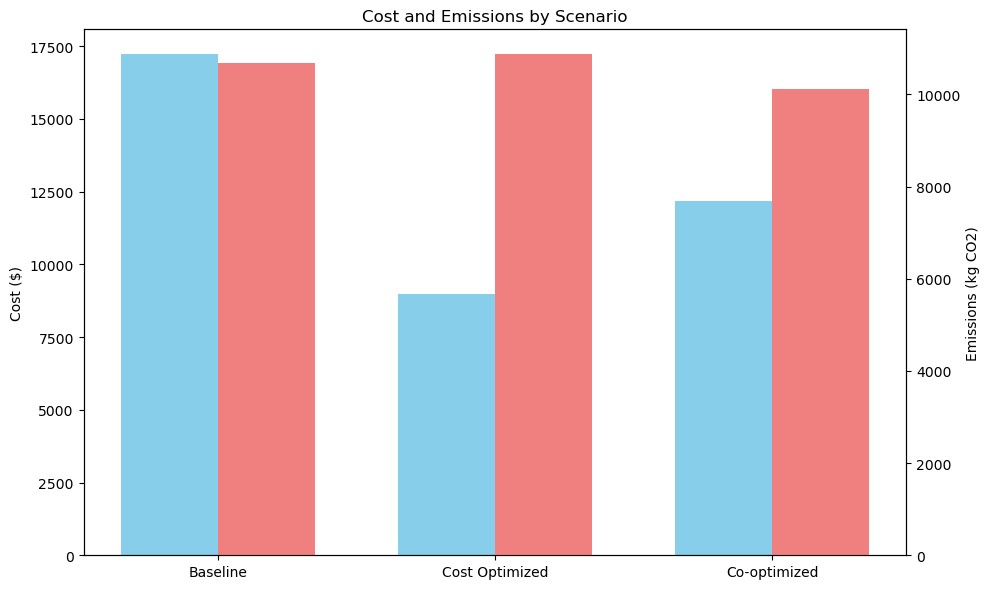

In [28]:
fig, ax1 = plt.subplots(figsize=(10, 6))

width = 0.35
x = range(len(results['Scenario']))

# Plotting Costs
rects1 = ax1.bar([i - width/2 for i in x], results['Cost ($)'], width, label='Cost ($)', color='skyblue')
# ax1.set_xlabel('Scenario')
ax1.set_ylabel('Cost ($)')
ax1.tick_params(axis='y')

# Creating a second y-axis for Emissions
ax2 = ax1.twinx()
rects2 = ax2.bar([i + width/2 for i in x], results['Emissions (kg CO2)'], width, label='Emissions (kg CO2)', color='lightcoral')
ax2.set_ylabel('Emissions (kg CO2)')
ax2.tick_params(axis='y')

ax1.set_xticks(x)
ax1.set_xticklabels(results['Scenario'])
ax1.set_title('Cost and Emissions by Scenario')
fig.tight_layout() # otherwise the right y-label is slightly clipped

# Add legends for both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.05,1.05))

plt.show()